# Dokumentasi Percobaan 1
## Klasifikasi Penyakit Daun Padi Menggunakan Kombinasi Fitur GLCM dan Transformasi Wavelet
### Pipeline: Grayscale + Resize + Normalisasi

## 1. Import Library

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from scipy.ndimage import convolve  # Digunakan untuk Haar Wavelet manual
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

### Penjelasan Kegunaan Library

| Library | Fungsi dalam Project |
|---|---|
| `cv2` (OpenCV) | Membaca gambar dari disk, konversi warna BGR→Grayscale, resize gambar, operasi flip dan rotasi untuk augmentasi |
| `numpy` | Operasi array dan matriks numerik; menyimpan data gambar sebagai array piksel bertipe `uint8` dan `float32` |
| `pandas` | Menyimpan hasil ekstraksi fitur GLCM dan Wavelet ke dalam tabel (DataFrame) dan mengekspor ke CSV |
| `skimage` | Menghitung matriks GLCM (`graycomatrix`) dan mengekstrak properti tekstur (`graycoprops`) seperti kontras, energi, homogenitas, dll. |
| `scipy` | Menghitung entropi dari distribusi GLCM (`entropy`) dan konvolusi 1D untuk implementasi Haar Wavelet manual (`convolve1d`) |
| `sklearn` | Membagi data train/test (`train_test_split`), melatih model RF/SVM/KNN, dan menghitung metrik evaluasi (akurasi, presisi, recall, F1) |
| `seaborn` | Memvisualisasikan heatmap korelasi antar fitur hasil ekstraksi |
| `matplotlib` | Menampilkan sampel gambar dataset, visualisasi preprocessing, dan grafik perbandingan model |

## 2. Data Loading

Pastikan struktur folder dataset sebagai berikut:
```
PROJECT-PCD-34/
├── dataset/
│   ├── blast/
│   │   ├── image1.jpg
│   │   └── ...
│   ├── blight/
│   │   ├── image1.jpg
│   │   └── ...
│   └── tungro/
│       ├── image1.jpg
│       └── ...
└── Percobaan_1.ipynb
```

> **Catatan:** Dataset ini memiliki **3 kelas** penyakit daun padi: `blast`, `blight`, dan `tungro`.

In [2]:
DATASET_PATH = "dataset"
TARGET_SIZE  = (512, 512)
KELAS_VALID  = ['blast', 'blight', 'tungro']

data      = []
labels    = []
file_name = []

for sub_folder in sorted(os.listdir(DATASET_PATH)):
    sub_folder_path = os.path.join(DATASET_PATH, sub_folder)

    if not os.path.isdir(sub_folder_path):
        continue
    if sub_folder not in KELAS_VALID:
        print(f"⚠️  Folder '{sub_folder}' dilewati (bukan kelas dataset)")
        continue

    sub_folder_files = os.listdir(sub_folder_path)
    print(f"📂 Memuat kelas '{sub_folder}': {len(sub_folder_files)} file...")

    for filename in sub_folder_files:
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            print(f"   ⚠️  Gagal membaca: {filename}")
            continue
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, TARGET_SIZE, interpolation=cv.INTER_AREA)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data      = np.array(data, dtype=np.uint8)
labels    = np.array(labels)

print()
print(f"✅ Total gambar berhasil dimuat: {len(data)}")
print(f"   Ukuran gambar : {data[0].shape}")
print(f"   Tipe data     : {data.dtype}")
print(f"📊 Distribusi per kelas:")
for kelas in KELAS_VALID:
    jumlah = np.sum(labels == kelas)
    print(f"   {kelas:10s}: {jumlah} gambar")

📂 Memuat kelas 'blast': 80 file...
📂 Memuat kelas 'blight': 80 file...
📂 Memuat kelas 'tungro': 80 file...

✅ Total gambar berhasil dimuat: 240
   Ukuran gambar : (512, 512)
   Tipe data     : uint8
📊 Distribusi per kelas:
   blast     : 80 gambar
   blight    : 80 gambar
   tungro    : 80 gambar


Kode ini memuat semua gambar dari tiga folder kelas penyakit daun padi **blast**, **blight**, dan **tungro** yang merupakan kelas target dari dataset Kaggle *Leaf Rice Disease Indonesia*. Setiap gambar langsung dikonversi ke **grayscale** dan di-resize ke ukuran seragam **(512×512 piksel)** saat proses loading.

**Mengapa dilakukan saat loading (bukan preprocessing terpisah)?**
- Grayscale dan resize adalah operasi dasar yang diperlukan di semua 5 percobaan, sehingga efisien jika dilakukan satu kali di awal.
- Konversi ke grayscale menghilangkan informasi warna (channel RGB) dan mereduksi dimensi data dari 3-channel menjadi 1-channel. Untuk ekstraksi fitur berbasis tekstur seperti **GLCM dan Wavelet**, informasi intensitas piksel dalam grayscale sudah cukup representatif — tekstur penyakit seperti bercak blast, hawar blight, dan perubahan warna tungro dapat dideteksi melalui pola intensitas.
- Resize ke 512×512 memastikan semua gambar memiliki dimensi seragam sehingga matriks GLCM dan dekomposisi Wavelet dapat diproses secara konsisten.

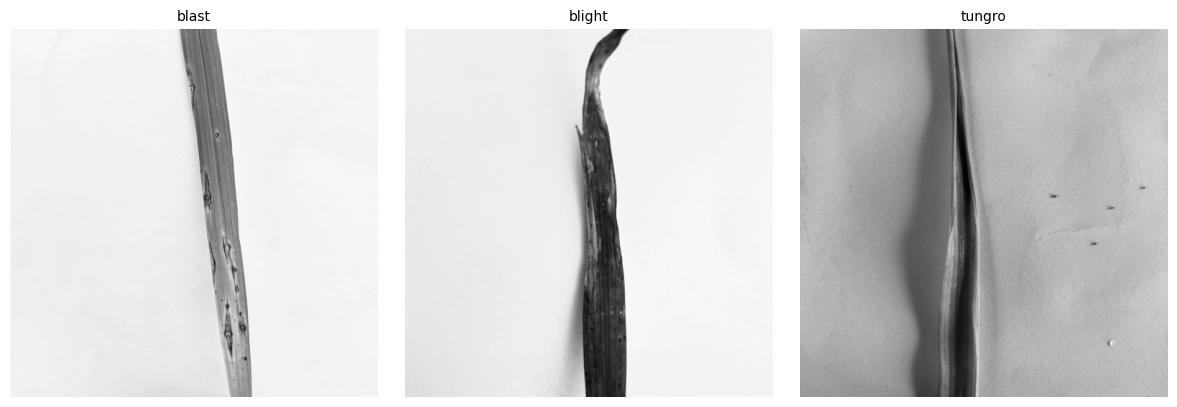

In [3]:
# VISUALISASI SAMPEL DATASET (1 gambar per kelas)

unique_labels = np.unique(labels)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels == kelas)[0][0]
    ax.imshow(data[idx], cmap='gray')
    ax.set_title(kelas, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Data Augmentation

In [4]:
data_augmented      = list(data)
labels_augmented    = list(labels)
file_name_augmented = list(file_name)

for i in range(len(data)):
    img   = data[i]
    label = labels[i]
    fname = file_name[i]
    name, ext = os.path.splitext(fname)

    # Flip Horizontal
    flipped_h = cv.flip(img, 1)
    data_augmented.append(flipped_h)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipH{ext}")

    # Flip Vertikal
    flipped_v = cv.flip(img, 0)
    data_augmented.append(flipped_v)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipV{ext}")

    # Rotasi 90°
    rotated = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)
    data_augmented.append(rotated)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_rot90{ext}")

data_augmented      = np.array(data_augmented, dtype=object)
labels_augmented    = np.array(labels_augmented)
file_name_augmented = np.array(file_name_augmented)

print(f"Data sebelum augmentasi : {len(data)}")
print(f"Data setelah augmentasi : {len(data_augmented)}")

Data sebelum augmentasi : 240
Data setelah augmentasi : 960


Data augmentasi dilakukan untuk **memperbanyak jumlah sampel training** dari 240 menjadi **960 gambar** (4× lipat). Setiap gambar asli menghasilkan 3 gambar tambahan:

- **Flip Horizontal**: Mencerminkan gambar secara horizontal. Berguna karena daun padi yang terinfeksi dapat muncul dari sisi kiri maupun kanan.
- **Flip Vertikal**: Mencerminkan gambar secara vertikal. Membantu model mengenali pola penyakit dari orientasi yang berbeda.
- **Rotasi 90°**: Memutar gambar searah jarum jam. Meningkatkan invariansi rotasi pada model.

**Mengapa augmentasi penting dalam project ini?**  
Dataset hanya memiliki 240 gambar (80 per kelas), yang tergolong kecil untuk melatih model machine learning. Augmentasi membantu:
- Mencegah overfitting karena model melihat variasi data yang lebih banyak.
- Meningkatkan kemampuan generalisasi model terhadap gambar baru yang mungkin memiliki orientasi berbeda.
- Menjaga keseimbangan kelas (setiap kelas tetap memiliki jumlah sama: 320 gambar).

## 4. Preprocessing — Percobaan 1

In [5]:
def resize(image, target_size=(512, 512)):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

def normalisasi(image):
    return image.astype(np.float32) / 255.0

def prepro1(image, target_size=(512, 512)):
    img = normalisasi(image)
    img_uint8 = (img * 255).astype(np.uint8)
    return img_uint8

Percobaan 1 berfungsi sebagai **baseline** (acuan minimum). Normalisasi skala piksel ke rentang [0, 1] kemudian dikembalikan ke uint8 memastikan nilai intensitas tetap konsisten. Tujuan utamanya adalah:

- Menstandarkan rentang nilai piksel agar tidak ada bias akibat perbedaan kecerahan antar gambar.
- Menjadi **pembanding** bagi percobaan 2–5 yang menggunakan langkah preprocessing tambahan (CLAHE, median filter, Gaussian blur, dll.).

Percobaan ini sengaja **tidak menggunakan** teknik peningkatan citra tambahan, sehingga hasil evaluasinya mencerminkan performa fitur GLCM+Wavelet pada kondisi gambar paling "natural" tanpa manipulasi kontras atau penghilangan noise.

In [6]:
dataPreprocessed = []

for i in range(len(data_augmented)):
    img_prep = prepro1(data_augmented[i], TARGET_SIZE)
    dataPreprocessed.append(img_prep)

dataPreprocessed = np.array(dataPreprocessed)

print(f"   Preprocessing selesai!")
print(f"   Jumlah gambar    : {len(dataPreprocessed)}")
print(f"   Ukuran gambar    : {dataPreprocessed[0].shape}")
print(f"   Tipe data        : {dataPreprocessed[0].dtype}")
print(f"   Nilai min / max  : {dataPreprocessed[0].min()} / {dataPreprocessed[0].max()}")

   Preprocessing selesai!
   Jumlah gambar    : 960
   Ukuran gambar    : (512, 512)
   Tipe data        : uint8
   Nilai min / max  : 55 / 246


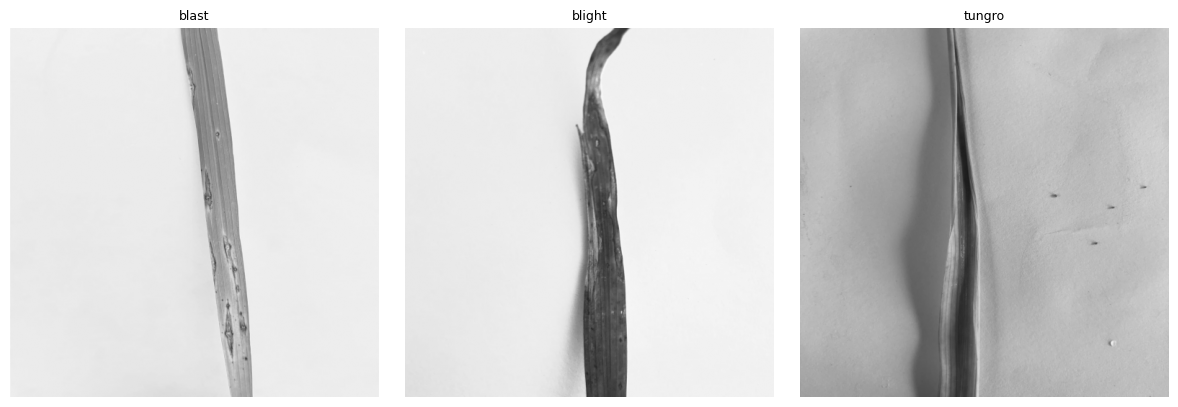

In [7]:
# VISUALISASI HASIL PREPROCESSING (1 sampel per kelas)

unique_labels = np.unique(labels_augmented)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]
    ax.imshow(dataPreprocessed[idx], cmap='gray', vmin=0, vmax=255)
    ax.set_title(kelas, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Ekstraksi Fitur GLCM

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan: 0, 45, 90, atau 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [9]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960


In [10]:
Kontras0, Kontras45, Kontras90, Kontras135                     = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135          = [], [], [], []
entropy0, entropy45, entropy90, entropy135                      = [], [], [], []
ASM0, ASM45, ASM90, ASM135                                      = [], [], [], []
energy0, energy45, energy90, energy135                          = [], [], [], []
correlation0, correlation45, correlation90, correlation135      = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

**Fitur yang diekstrak untuk setiap sudut (0°, 45°, 90°, 135°):**
- Contrast
- Dissimilarity
- Homogeneity
- Entropy
- ASM (Angular Second Moment)
- Energy
- Correlation

**GLCM (Gray-Level Co-occurrence Matrix)** adalah metode ekstraksi fitur tekstur yang menganalisis hubungan spasial antara pasangan piksel pada jarak dan sudut tertentu. Dalam project ini:

- **Jarak (d = 1)**: Menganalisis pasangan piksel yang bertetangga langsung (adjacent). Jarak 1 cocok untuk menangkap tekstur halus dari bercak atau lesion penyakit pada daun.
- **4 Sudut (0°, 45°, 90°, 135°)**: Menganalisis pola tekstur dari 4 arah berbeda untuk menangkap sifat tekstur yang mungkin tidak isotropik (berbeda tergantung arah). Pola lesi *blast* misalnya, cenderung memiliki tekstur berbeda dibandingkan *blight* saat dianalisis dari sudut horizontal vs diagonal.
- **`symmetric=True`**: Memastikan matriks simetris sehingga hasil lebih stabil.
- **`normed=True`**: Normalisasi matriks menjadi distribusi probabilitas.

Total fitur GLCM yang dihasilkan: **7 fitur × 4 sudut = 28 fitur GLCM**.


## 6. Ekstraksi Fitur Wavelet (Haar — Implementasi Manual)

In [11]:
HAAR_LP = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HAAR_HP = np.array([1/np.sqrt(2), -1/np.sqrt(2)])

def haar_dwt2d_level1(image):
    img = image.astype(np.float32)

    from scipy.ndimage import convolve1d
    L_row = convolve1d(img,    HAAR_LP, axis=1, mode='wrap')[:, ::2]
    H_row = convolve1d(img,    HAAR_HP, axis=1, mode='wrap')[:, ::2]

    LL = convolve1d(L_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    LH = convolve1d(L_row, HAAR_HP, axis=0, mode='wrap')[::2, :]
    HL = convolve1d(H_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    HH = convolve1d(H_row, HAAR_HP, axis=0, mode='wrap')[::2, :]

    return LL, LH, HL, HH


def ekstraksi_wavelet(image, level=2):
    fitur = []
    current = image.astype(np.float32)

    for lv in range(1, level + 1):
        LL, LH, HL, HH = haar_dwt2d_level1(current)

        if lv == level:
            fitur.append(np.mean(LL))
            fitur.append(np.std(LL))

        # Detail sub-bands setiap level
        fitur.append(np.mean(LH));  fitur.append(np.std(LH))
        fitur.append(np.mean(HL));  fitur.append(np.std(HL))
        fitur.append(np.mean(HH));  fitur.append(np.std(HH))

        # LL menjadi input level berikutnya
        current = LL

    return fitur

**Haar Wavelet** diimplementasikan secara manual menggunakan filter low-pass (`HAAR_LP`) dan high-pass (`HAAR_HP`) yang dikonvolusi pada baris dan kolom gambar. Proses ini menghasilkan 4 sub-band:

| Sub-band | Representasi |
|---|---|
| **LL** | Aproksimasi gambar (frekuensi rendah) — informasi global daun |
| **LH** | Detail tepi horizontal (frekuensi tinggi arah vertikal) — batas lesi |
| **HL** | Detail tepi vertikal (frekuensi tinggi arah horizontal) — pola urat daun |
| **HH** | Detail diagonal (frekuensi tinggi kedua arah) — tekstur halus lesi |

Dekomposisi dilakukan **2 level** untuk menangkap informasi tekstur di skala berbeda. Fitur yang diekstrak dari setiap sub-band adalah **mean** dan **std**, menghasilkan total **14 fitur Wavelet**.

Total fitur gabungan = **28 (GLCM) + 14 (Wavelet) = 42 fitur**.

## 7. Simpan Hasil Ekstraksi ke CSV

In [12]:
wavelet_features = []
for i in range(len(dataPreprocessed)):
    wav_feat = ekstraksi_wavelet(dataPreprocessed[i], level=2)
    wavelet_features.append(wav_feat)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

wavelet_features = np.array(wavelet_features)

n_wav = wavelet_features.shape[1]
wav_col_names = (
    ['Wav_LL_mean', 'Wav_LL_std'] +
    ['Wav_LH_L2_mean', 'Wav_LH_L2_std',
     'Wav_HL_L2_mean', 'Wav_HL_L2_std',
     'Wav_HH_L2_mean', 'Wav_HH_L2_std'] +
    ['Wav_LH_L1_mean', 'Wav_LH_L1_std',
     'Wav_HL_L1_mean', 'Wav_HL_L1_std',
     'Wav_HH_L1_mean', 'Wav_HH_L1_std']
)

# Buat dictionary semua fitur
dataTable = {
    'Filename' : file_name_augmented,
    'Label'    : labels_augmented,
    # GLCM Features
    'Contrast0': Kontras0,     'Contrast45': Kontras45,     'Contrast90': Kontras90,     'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,      'Entropy45': entropy45,      'Entropy90': entropy90,      'Entropy135': entropy135,
    'ASM0': ASM0,              'ASM45': ASM45,              'ASM90': ASM90,              'ASM135': ASM135,
    'Energy0': energy0,        'Energy45': energy45,        'Energy90': energy90,        'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

# Tambahkan fitur Wavelet
for j, col in enumerate(wav_col_names):
    dataTable[col] = wavelet_features[:, j]

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
print(f"   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan1.csv'")
print(f"   Shape DataFrame: {hasilEkstrak.shape}")
hasilEkstrak.head()

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960
   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan1.csv'
   Shape DataFrame: (960, 44)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Wav_HL_L2_mean,Wav_HL_L2_std,Wav_HH_L2_mean,Wav_HH_L2_std,Wav_LH_L1_mean,Wav_LH_L1_std,Wav_HL_L1_mean,Wav_HL_L1_std,Wav_HH_L1_mean,Wav_HH_L1_std
0,IMG_0448.jpg,blast,33.313861,29.673879,3.568111,39.387774,0.864622,0.831688,0.878902,0.828582,...,-0.000153,1.096874,912.18140,93.25115,-0.005249,3.598037,-0.055298,14.337417,-0.004730,2.862293
1,IMG_0535.jpg,blast,22.588915,24.309669,1.304668,22.480796,0.883942,0.843204,0.896404,0.845034,...,0.001183,0.529958,867.93164,149.97064,-0.355118,2.827464,0.160965,15.587863,0.000015,1.658592
2,IMG_0536.jpg,blast,46.685562,51.339073,5.031200,47.048893,0.687059,0.625375,0.733355,0.625606,...,0.000702,1.109942,669.52580,162.58595,-0.473175,4.413202,-0.246216,19.232374,-0.003052,3.381107
3,IMG_0541.jpg,blast,25.973340,32.958326,5.410084,25.698048,0.696578,0.604473,0.686095,0.601128,...,-0.000359,1.028103,647.58466,156.98883,-0.401444,5.211432,0.147354,14.971980,-0.001267,3.154252
4,IMG_0543.jpg,blast,24.355083,26.674178,3.355683,26.351929,0.694243,0.621661,0.730043,0.613789,...,0.001221,0.766396,656.49225,148.65826,-0.092102,4.043725,-0.194794,15.176646,0.000641,2.457724


Seluruh fitur GLCM (28 fitur) dan Wavelet (14 fitur) disimpan bersama label dan nama file ke dalam **CSV** (`hasil_ekstraksi_percobaan1.csv`). File ini berdimensi **(960 baris × 44 kolom)** — 42 kolom fitur + kolom `Filename` + kolom `Label`.

Penyimpanan ke CSV berguna untuk:
- Menghindari komputasi ulang yang mahal (ekstraksi GLCM pada 960 gambar memerlukan waktu signifikan).
- Memudahkan analisis eksplorasi fitur (EDA) secara terpisah.
- Memungkinkan reproduksibilitas eksperimen: data fitur dapat di-load ulang tanpa memproses ulang gambar.

## 8. Feature Selection (Korelasi)

In [13]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : {hasilEkstrak.drop(columns=['Label','Filename']).shape[1]}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")
print(f"Fitur yang dipilih    : {list(select)}")

Fitur sebelum seleksi : 42
Fitur setelah seleksi : 26
Fitur yang dipilih    : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135', 'Wav_LL_mean', 'Wav_LH_L2_mean', 'Wav_HL_L2_mean', 'Wav_HL_L2_std', 'Wav_HH_L2_mean', 'Wav_HH_L2_std', 'Wav_LH_L1_mean', 'Wav_LH_L1_std', 'Wav_HL_L1_mean', 'Wav_HL_L1_std', 'Wav_HH_L1_mean', 'Wav_HH_L1_std']


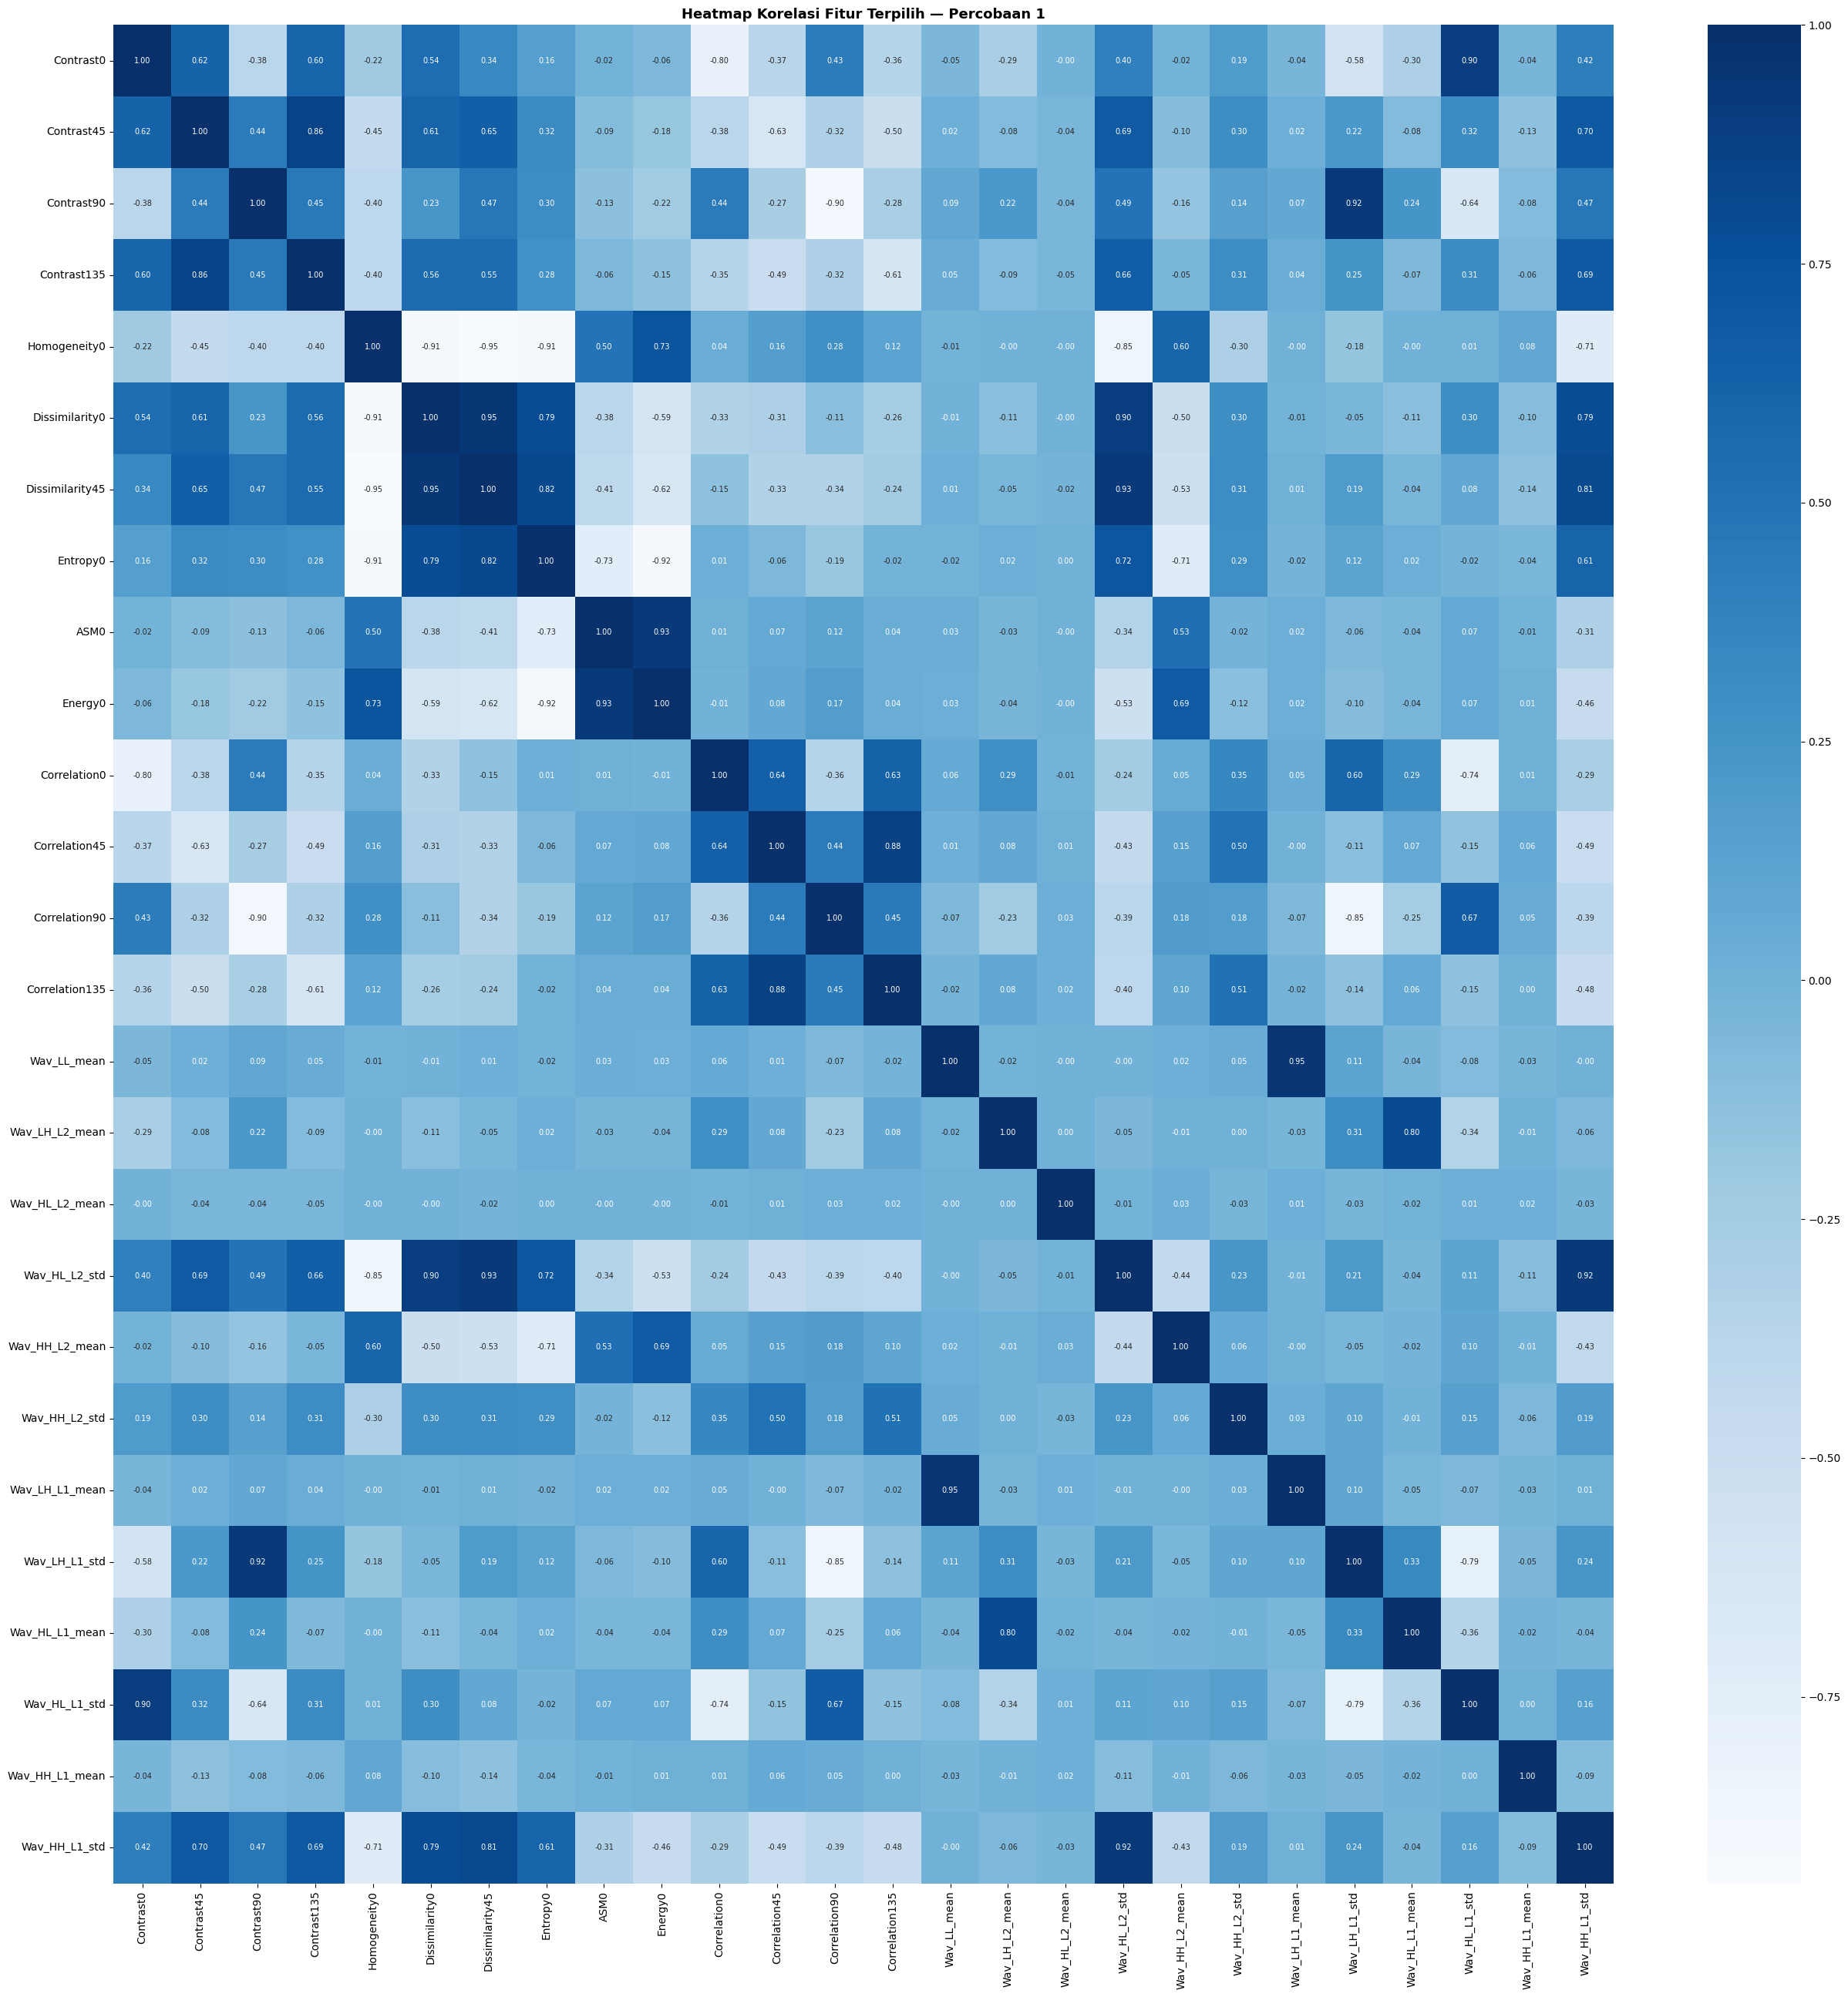

In [14]:
plt.figure(figsize=(max(12, x_new.shape[1]), max(10, x_new.shape[1])))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f",
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Terpilih — Percobaan 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Mengapa Hanya 26 Fitur yang Terpilih?

Metode seleksi ini menghilangkan **fitur yang berkorelasi tinggi (≥ 0.95)** dengan fitur lain. Artinya, jika dua fitur hampir identik secara statistik, hanya salah satunya yang dipertahankan. Ini disebut **penghilangan redundansi fitur**.

**Mengapa ini perlu?**

Fitur GLCM dari 4 sudut (0°, 45°, 90°, 135°) seringkali sangat berkorelasi satu sama lain. Misalnya, nilai *Homogeneity* pada sudut 0° dan *Homogeneity* pada sudut 90° dapat memberikan informasi yang hampir sama jika pola tekstur gambar cenderung isotropik. Memasukkan keduanya ke model hanya menambah dimensi tanpa informasi baru — bahkan dapat merugikan model:

- **KNN**: Jarak Euclidean antar sampel terdistorsi oleh fitur redundan.
- **SVM**: Margin hyperplane terpengaruh oleh fitur dengan korelasi tinggi.
- **Random Forest**: Pohon keputusan cenderung memilih fitur korelasi tinggi secara berulang, mengurangi diversitas ensemble.

**Fitur yang bertahan (26 fitur):** Kombinasi fitur kontras, homogenitas, dissimilarity, entropy, ASM, energi, korelasi dari sudut-sudut yang memberi informasi paling unik, ditambah seluruh fitur Wavelet yang relatif lebih beragam karena merepresentasikan skala frekuensi berbeda.

### Heatmap Korelasi

Pada heatmap, warna **biru tua** menandakan korelasi tinggi (mendekati ±1.0). Pasangan fitur dengan korelasi ≥ 0.95 (blok biru tua) adalah pasangan yang satu di antaranya dieliminasi. Fitur yang tersisa (26 fitur) adalah himpunan fitur paling **tidak redundan** yang memaksimalkan keragaman informasi untuk proses klasifikasi.

## 10. Normalisasi Fitur (Z-Score Standardization)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

train_mean = X_train.mean()
train_std  = X_train.std()

# Hindari pembagian dengan nol
train_std = train_std.replace(0, 1)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print("Normalisasi Z-Score selesai!")
print(f"   X_train setelah normalisasi: mean ≈ {X_train_norm.mean().mean():.4f}, std ≈ {X_train_norm.std().mean():.4f}")
print(f"   X_test  setelah normalisasi: mean ≈ {X_test_norm.mean().mean():.4f}")

Normalisasi Z-Score selesai!
   X_train setelah normalisasi: mean ≈ 0.0000, std ≈ 1.0000
   X_test  setelah normalisasi: mean ≈ -0.0157


**Z-Score Standardization** mengubah setiap fitur agar memiliki **mean ≈ 0 dan std ≈ 1**. Ini penting karena:

- Fitur GLCM seperti *Contrast* memiliki nilai ratusan (misal: 33.31), sementara fitur *Energy* bernilai sangat kecil (misal: 0.0003). Tanpa normalisasi, model berbasis jarak (KNN) dan berbasis margin (SVM) akan didominasi oleh fitur dengan skala besar.
- Normalisasi dilakukan **hanya berdasarkan data training** (`train_mean`, `train_std`), kemudian parameter yang sama diaplikasikan ke data testing. Ini mencegah *data leakage* — informasi dari data test tidak boleh mempengaruhi proses training.
- Pembagian data menggunakan `stratify=y` memastikan proporsi kelas (blast:blight:tungro) tetap seimbang di training set maupun testing set.

**Rasio split: 80% training (768 sampel) / 20% testing (192 sampel).**

## 11. Pemodelan & Klasifikasi

In [16]:
def generateClassificationReport(y_true, y_pred, set_name=""):
    print(f"\n{'='*55}")
    print(f"  {set_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# Definisi model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

print("Model berhasil didefinisikan!")
print("   - Random Forest  : n_estimators=100")
print("   - SVM            : kernel=RBF, C=1.0")
print("   - KNN            : n_neighbors=5")

Model berhasil didefinisikan!
   - Random Forest  : n_estimators=100
   - SVM            : kernel=RBF, C=1.0
   - KNN            : n_neighbors=5


In [17]:
print("\n RANDOM FOREST CLASSIFIER")
print("="*55)

rf.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_rf_train = rf.predict(X_train_norm)
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = generateClassificationReport(
    y_train, y_pred_rf_train, "RF — Training Set")

print("\n---------- Testing Set ----------")
y_pred_rf_test = rf.predict(X_test_norm)
rf_test_acc, rf_test_prec, rf_test_rec, rf_test_f1 = generateClassificationReport(
    y_test, y_pred_rf_test, "RF — Testing Set")


 RANDOM FOREST CLASSIFIER

---------- Training Set ----------

  RF — Training Set
              precision    recall  f1-score   support

       blast       1.00      1.00      1.00       256
      blight       1.00      1.00      1.00       256
      tungro       1.00      1.00      1.00       256

    accuracy                           1.00       768
   macro avg       1.00      1.00      1.00       768
weighted avg       1.00      1.00      1.00       768

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

---------- Testing Set ----------

  RF — Testing Set
              precision    recall  f1-score   support

       blast       0.98      0.94      0.96        64
      blight       0.97      1.00      0.98        64
      tungro       0.94      0.95      0.95        64

    accuracy                           0.96       192
   macro avg       0.96      0.96      0.96       192
weighted avg       0.96      0.96      0.96       192

  Accuracy  : 0

In [18]:
print("\n  SVM CLASSIFIER")
print("="*55)

svm.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_svm_train = svm.predict(X_train_norm)
svm_train_acc, svm_train_prec, svm_train_rec, svm_train_f1 = generateClassificationReport(
    y_train, y_pred_svm_train, "SVM — Training Set")

print("\n---------- Testing Set ----------")
y_pred_svm_test = svm.predict(X_test_norm)
svm_test_acc, svm_test_prec, svm_test_rec, svm_test_f1 = generateClassificationReport(
    y_test, y_pred_svm_test, "SVM — Testing Set")


  SVM CLASSIFIER

---------- Training Set ----------

  SVM — Training Set
              precision    recall  f1-score   support

       blast       0.88      0.89      0.88       256
      blight       0.92      0.96      0.94       256
      tungro       0.87      0.82      0.85       256

    accuracy                           0.89       768
   macro avg       0.89      0.89      0.89       768
weighted avg       0.89      0.89      0.89       768

  Accuracy  : 0.8893
  Precision : 0.8886
  Recall    : 0.8893
  F1-Score  : 0.8886

---------- Testing Set ----------

  SVM — Testing Set
              precision    recall  f1-score   support

       blast       0.85      0.78      0.81        64
      blight       0.88      0.94      0.91        64
      tungro       0.77      0.78      0.78        64

    accuracy                           0.83       192
   macro avg       0.83      0.83      0.83       192
weighted avg       0.83      0.83      0.83       192

  Accuracy  : 0.8333
 

In [19]:
print("\n KNN CLASSIFIER")
print("="*55)

knn.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_knn_train = knn.predict(X_train_norm)
knn_train_acc, knn_train_prec, knn_train_rec, knn_train_f1 = generateClassificationReport(
    y_train, y_pred_knn_train, "KNN — Training Set")

print("\n---------- Testing Set ----------")
y_pred_knn_test = knn.predict(X_test_norm)
knn_test_acc, knn_test_prec, knn_test_rec, knn_test_f1 = generateClassificationReport(
    y_test, y_pred_knn_test, "KNN — Testing Set")


 KNN CLASSIFIER

---------- Training Set ----------

  KNN — Training Set
              precision    recall  f1-score   support

       blast       0.76      0.91      0.83       256
      blight       0.90      0.94      0.92       256
      tungro       0.88      0.66      0.76       256

    accuracy                           0.84       768
   macro avg       0.84      0.84      0.83       768
weighted avg       0.84      0.84      0.83       768

  Accuracy  : 0.8359
  Precision : 0.8433
  Recall    : 0.8359
  F1-Score  : 0.8324

---------- Testing Set ----------

  KNN — Testing Set
              precision    recall  f1-score   support

       blast       0.76      0.86      0.81        64
      blight       0.88      0.92      0.90        64
      tungro       0.85      0.70      0.77        64

    accuracy                           0.83       192
   macro avg       0.83      0.83      0.83       192
weighted avg       0.83      0.83      0.83       192

  Accuracy  : 0.8281
  

**Random Forest** (`n_estimators=100`): Membangun 100 pohon keputusan dari subset acak data dan fitur. Setiap pohon memberikan "suara", dan kelas mayoritas menjadi prediksi akhir. Cocok untuk dataset dengan fitur tekstur karena tahan terhadap overfitting dan mampu menangani fitur yang saling berinteraksi.

**SVM** (`kernel=RBF`, `C=1.0`, `gamma='scale'`): Kernel RBF (*Radial Basis Function*) memetakan data ke dimensi tinggi untuk menemukan hyperplane pemisah non-linear. `C=1.0` adalah nilai regularisasi standar, dan `gamma='scale'` menyesuaikan skala kernel secara otomatis berdasarkan variance fitur. SVM efektif ketika margin antar kelas cukup jelas di ruang fitur.

**KNN** (`n_neighbors=5`): Mengklasifikasikan berdasarkan 5 tetangga terdekat. Sederhana namun sensitif terhadap skala fitur — oleh karena itu normalisasi Z-Score sebelumnya sangat krusial untuk KNN.

## 12. Evaluasi — Confusion Matrix

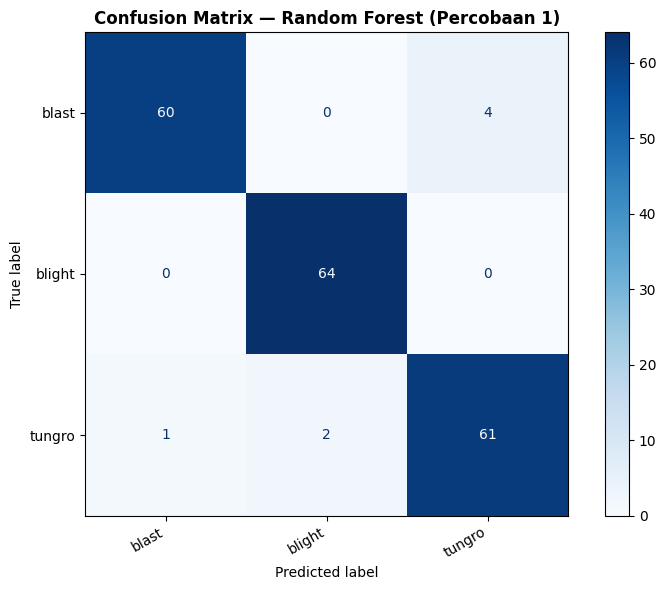

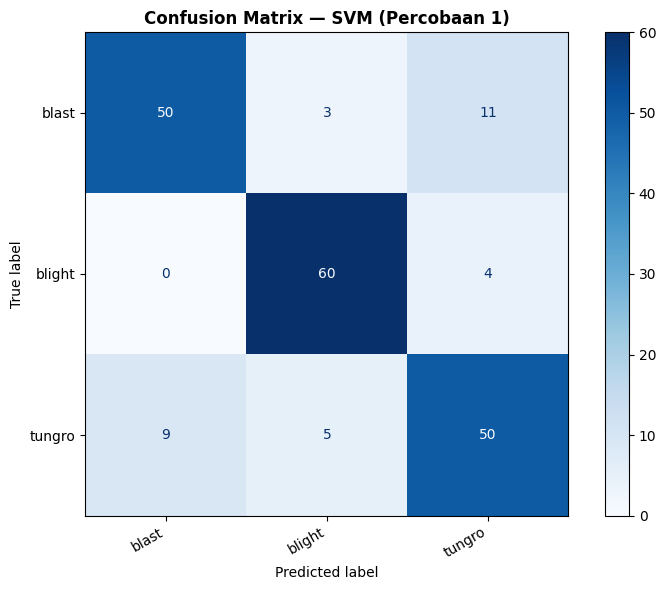

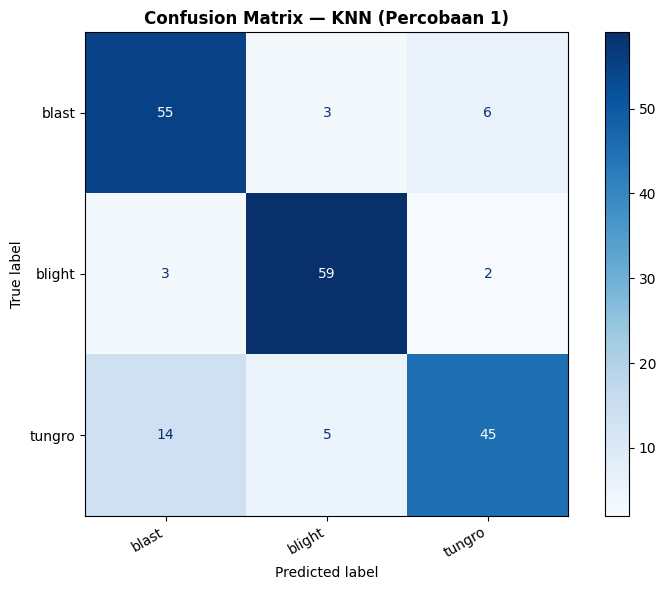

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test,  "Confusion Matrix — Random Forest (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix — SVM (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_knn_test, "Confusion Matrix — KNN (Percobaan 1)")

Confusion matrix menampilkan jumlah prediksi **benar** (diagonal utama) dan **salah** (elemen off-diagonal) untuk setiap kombinasi kelas aktual vs kelas prediksi. Dari confusion matrix dapat diidentifikasi:

- Kelas mana yang paling sering salah diklasifikasikan.
- Pola kesalahan spesifik (misalnya: *blast* sering salah diprediksi sebagai *tungro*).
- Kinerja model per kelas, bukan hanya akurasi keseluruhan.

**Observasi dari Confusion Matrix Percobaan 1:**
- **Random Forest**: Kesalahan hanya pada blast (4 salah ke tungro) dan tungro (1 ke blast, 2 ke blight). Blight sempurna (64/64).
- **SVM**: Kesalahan terbesar ada pada tungro (9 salah ke blast, 5 ke blight), dan blast (11 salah ke tungro). Menunjukkan SVM kesulitan memisahkan blast–tungro.
- **KNN**: Tungro memiliki kesalahan terbesar (14 salah ke blast, 5 ke blight), menandakan fitur kurang mampu membedakan tungro dari blast.

## 13. Ringkasan Hasil Percobaan 1

In [21]:
hasil_summary = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train' : [rf_train_acc,  svm_train_acc,  knn_train_acc],
    'Accuracy_Test'  : [rf_test_acc,   svm_test_acc,   knn_test_acc],
    'Precision_Test' : [rf_test_prec,  svm_test_prec,  knn_test_prec],
    'Recall_Test'    : [rf_test_rec,   svm_test_rec,   knn_test_rec],
    'F1_Score_Test'  : [rf_test_f1,    svm_test_f1,    knn_test_f1],
})

print(hasil_summary.to_string(index=False))

hasil_summary.to_csv('hasil_percobaan1.csv', index=False)

        Model  Accuracy_Train  Accuracy_Test  Precision_Test  Recall_Test  F1_Score_Test
Random Forest        1.000000       0.963542        0.963922     0.963542       0.963451
          SVM        0.889323       0.833333        0.833014     0.833333       0.832431
          KNN        0.835938       0.828125        0.831181     0.828125       0.826273


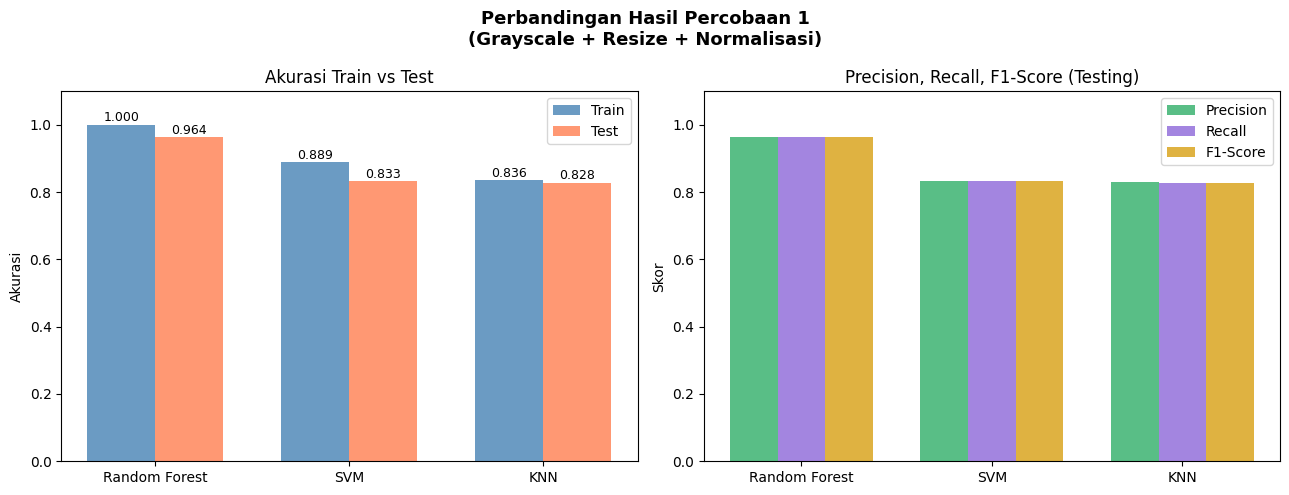

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Hasil Percobaan 1\n(Grayscale + Resize + Normalisasi)',
             fontsize=13, fontweight='bold')

models = hasil_summary['Model']
x = np.arange(len(models))
width = 0.35

# Grafik Akurasi Train vs Test
axes[0].bar(x - width/2, hasil_summary['Accuracy_Train'], width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, hasil_summary['Accuracy_Test'],  width, label='Test',  color='coral',     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Akurasi')
axes[0].set_title('Akurasi Train vs Test')
axes[0].legend()
for xi, (tr, te) in enumerate(zip(hasil_summary['Accuracy_Train'], hasil_summary['Accuracy_Test'])):
    axes[0].text(xi - width/2, tr + 0.01, f"{tr:.3f}", ha='center', fontsize=9)
    axes[0].text(xi + width/2, te + 0.01, f"{te:.3f}", ha='center', fontsize=9)

# Grafik Precision, Recall, F1
w = 0.25
axes[1].bar(x - w, hasil_summary['Precision_Test'], w, label='Precision', color='mediumseagreen', alpha=0.85)
axes[1].bar(x,     hasil_summary['Recall_Test'],    w, label='Recall',    color='mediumpurple',   alpha=0.85)
axes[1].bar(x + w, hasil_summary['F1_Score_Test'],  w, label='F1-Score',  color='goldenrod',      alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Skor')
axes[1].set_title('Precision, Recall, F1-Score (Testing)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Hasil Lengkap

| Model | Accuracy Train | Accuracy Test | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| **Random Forest** | 1.0000 | **0.9635** | **0.9639** | **0.9635** | **0.9635** |
| SVM | 0.8893 | 0.8333 | 0.8330 | 0.8333 | 0.8324 |
| KNN | 0.8359 | 0.8281 | 0.8312 | 0.8281 | 0.8263 |

---

### Perbandingan Mendalam: Random Forest vs SVM vs KNN

#### 🌳 Random Forest — Terbaik (Akurasi Test: 96.35%)

Random Forest unggul jauh di Percobaan 1. Dengan training accuracy 100% dan test accuracy 96.35%, selisih yang kecil (~3.65%) menandakan model **tidak overfitting secara signifikan** meski training sempurna. Hal ini karena RF secara alami memiliki mekanisme regularisasi internal melalui *bagging* dan pemilihan fitur acak.

Keunggulan RF pada dataset ini disebabkan oleh kemampuannya menangani:
- Kombinasi fitur GLCM (statistik tekstur global) + Wavelet (informasi frekuensi multi-skala) yang heterogen skalanya.
- Interaksi non-linear antar fitur — pola penyakit daun padi tidak dapat dipisahkan hanya dengan satu aturan linear.

#### ⚡ SVM — Menengah (Akurasi Test: 83.33%)

SVM dengan kernel RBF menghasilkan akurasi test yang lebih rendah dibanding RF. Gap antara training (88.93%) dan test (83.33%) menunjukkan adanya sedikit overfitting. Kelemahan utama terlihat dari confusion matrix: **blast dan tungro sering tertukar** (11 blast salah ke tungro, 9 tungro salah ke blast), mengindikasikan fitur baseline (tanpa peningkatan kontras) belum cukup memisahkan kedua kelas ini di ruang kernel RBF.

SVM berpotensi meningkat pada percobaan dengan preprocessing lebih kuat (CLAHE) yang memperjelas perbedaan tekstur antar kelas.

#### 🔵 KNN — Terendah (Akurasi Test: 82.81%)

KNN dengan k=5 menghasilkan performa terendah, dengan gap training (83.59%) dan test (82.81%) yang sangat kecil — menandakan model **tidak overfitting**, namun **underfitting** secara umum. KNN bergantung penuh pada jarak Euclidean antar sampel di ruang fitur 26 dimensi. Pada dimensi tinggi, jarak antar sampel cenderung seragam (*curse of dimensionality*), sehingga k=5 tetangga terdekat tidak selalu representatif.

Kesalahan terbesar KNN pada kelas **tungro** (14 dari 64 salah ke blast) konsisten dengan SVM, menunjukkan bahwa fitur tanpa preprocessing peningkatan kontras memang memiliki keterbatasan dalam memisahkan tungro dari blast.

---

### Kesimpulan Percobaan 1

Percobaan 1 sebagai baseline berhasil membuktikan bahwa **kombinasi fitur GLCM + Wavelet sudah mampu mengklasifikasikan penyakit daun padi** bahkan tanpa preprocessing tambahan.

**Poin kunci:**
1. **Random Forest adalah model terkuat** untuk kombinasi fitur GLCM+Wavelet pada dataset ini, dengan akurasi 96.35% meski hanya menggunakan preprocessing minimal.
2. **SVM dan KNN memberikan performa serupa (~83%)**, keduanya kesulitan pada kelas tungro yang tampaknya memiliki fitur tekstur paling berdekatan dengan blast.
3. **Preprocessing yang lebih kuat diharapkan meningkatkan SVM dan KNN** (Percobaan 2–5), sementara RF kemungkinan sudah mendekati batas atas performanya.
4. **Kelas blight paling mudah diklasifikasikan** oleh semua model, mengindikasikan tekstur *blight* paling distinktif di antara ketiga kelas.
5. Seleksi fitur (42 → 26 fitur) berhasil menghilangkan redundansi tanpa menurunkan performa, bahkan membantu model lebih efisien dan stabil.

> **Benchmark untuk percobaan selanjutnya:** RF = 96.35% | SVM = 83.33% | KNN = 82.81%